In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'dog.jpeg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(350, 233, 3)

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

_, otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pixels = np.float32(img.reshape(-1, 3))
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, centers = cv2.kmeans(pixels, 4, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
kmeans = np.uint8(centers)[labels.flatten()].reshape(img.shape)

canny = cv2.Canny(blurred, 50, 150)

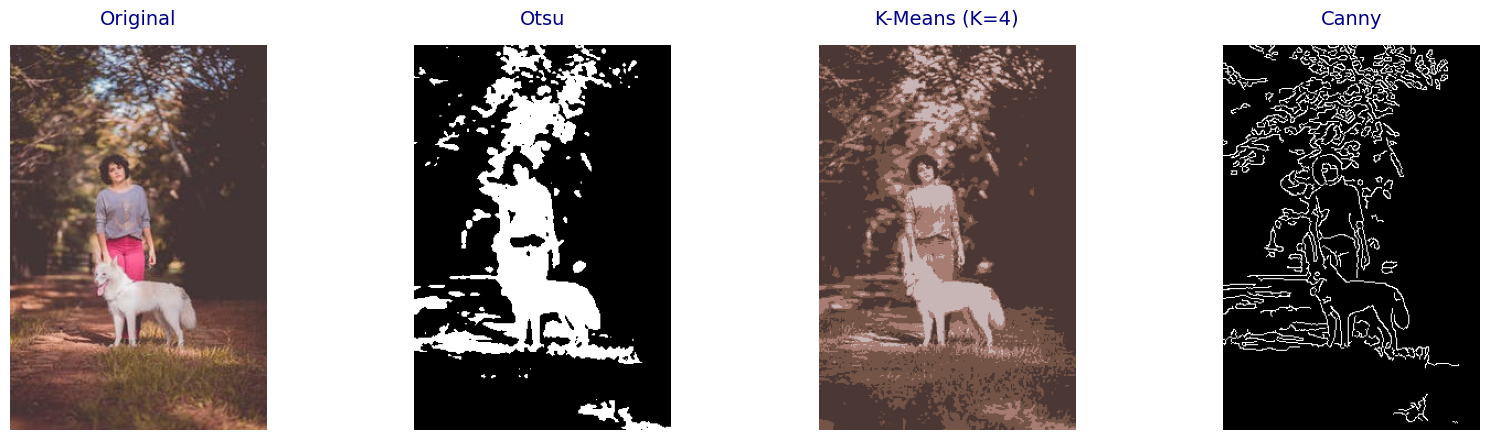

In [4]:
panels = [('Original', img), ('Otsu', otsu), ('K-Means (K=4)', kmeans), ('Canny', canny)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task10_otsu.png', otsu)
cv2.imwrite('output/task10_kmeans.png', cv2.cvtColor(kmeans, cv2.COLOR_RGB2BGR))
cv2.imwrite('output/task10_canny.png', canny)

True

Otsu assumes the image has a bright and a dark class. It finds the dog, the person and bright patches in the trees. It gets bright leaves and ground wrong by mixing them with the dog and person, and the dark parts of the person are lost. The blur before thresholding has the most effect.

K-Means (K=4) assumes the same object has similar color. It finds the dog, person, lit ground and dark background. It merges the pink trousers with the ground color. K has the most effect.

Canny assumes boundaries are sharp intensity changes. It finds the outline of the dog and person. Trees and grass give lots of unwanted edges and the outlines are broken. The high and low thresholds have the most effect.

Conclusion: K-Means gave the most meaningful regions here. The dog, person and background are different colors and K-Means groups by color. Otsu mixes the bright leaves in with the subjects and Canny only gives edges, with a lot of noise from the trees.